In [31]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import treecorr

In [32]:
#load in data

# fits_file = fits.util.get_testdata_filepath("23586.fits")
hdul = fits.open("23778.fits")
hdul.info()
hdr = hdul[1].header
data = hdul[1].data

z = data['true_redshift_gal']

# ra = data['ra_gal']
# dec = data['dec_gal']
# print(np.min(ra), np.max(ra))
# print(np.min(dec), np.max(dec))

#create mask in redshift:
z_min = 0.8
z_max = 1
#create mask in ra dec
# ra_min = 
mask = np.where((z > z_min) & (z < z_max))

x = data['x_gal'][mask]
y = data['y_gal'][mask]
z = data['z_gal'][mask]

ra = data['ra_gal'][mask]
dec = data['dec_gal'][mask]

kappa = data['kappa'][mask]

gamma1 = data['gamma1'][mask]
gamma2 = data['gamma2'][mask]

eps1 = data['eps1_gal'][mask]
eps2 = data['eps2_gal'][mask]

Filename: 23778.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     61   69482681R x 18C   [E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E]   


In [33]:
nbins = 10
min_sep = 1/3600
max_sep = 10/3600

log_min = np.log10(min_sep)
log_max = np.log10(max_sep)
dlog = (log_max - log_min) / nbins

theta = 10**(log_min + (np.arange(nbins) + 0.5) * dlog) 

In [34]:
#setup config for treecorr
config = {
    "nbins": nbins,
    "min_sep":  min_sep,
    "max_sep": max_sep,
    "sep_units": "degrees",
    "bin_type": "Log",

    # "min_rpar": PI_max,
    # "max_rpar": PI_max,

    "bin_slop": None,
    #"angle_slop": None,

    # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
    "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
    "var_method": 'jackknife',
    "cross_patch_weight": 'match',
}

In [35]:
def get_cov(config, npatch, method='jackknife', including_shear=False):
    if including_shear:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1 + gamma1, g2=eps2 +gamma2, npatch=npatch
        )
    else:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1, g2=eps2, npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat)
    cov = gg.estimate_cov(method=method, cross_patch_weight='match')

    return cov

In [36]:
npatch = 30

IA_cov = get_cov(config, npatch=npatch, including_shear=False)
GLIA_cov = get_cov(config, npatch=npatch, including_shear=True)


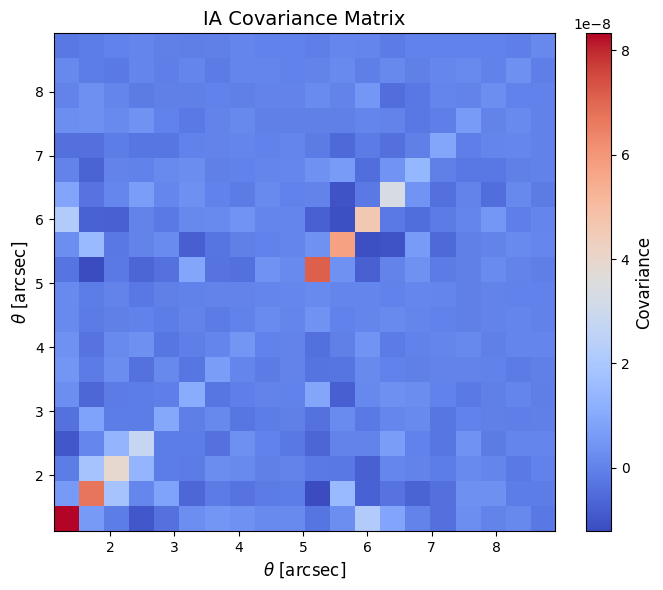

In [37]:
plt.figure(figsize=(7,6))
theta_as = 3600 * theta
extent = [theta_as[0], theta_as[-1], theta_as[0], theta_as[-1]] 

im = plt.imshow(
    IA_cov,
    origin='lower',
    cmap='coolwarm',
    aspect='auto',
    extent=extent
)

# plt.xscale("log")
# plt.yscale("log")

cbar = plt.colorbar(im)
cbar.set_label("Covariance", fontsize=12)

plt.title("IA Covariance Matrix", fontsize=14)
plt.xlabel(r"$\theta$ [arcsec]", fontsize=12)
plt.ylabel(r"$\theta$ [arcsec]", fontsize=12)

plt.tight_layout()
plt.show()

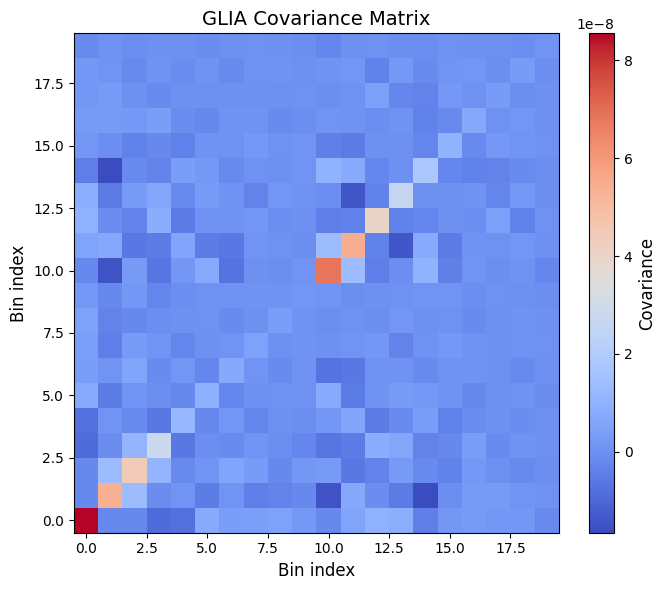

In [38]:
plt.figure(figsize=(7,6))

im = plt.imshow(
    GLIA_cov,
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)

cbar = plt.colorbar(im)
cbar.set_label('Covariance', fontsize=12)

plt.title('GLIA Covariance Matrix', fontsize=14)
plt.xlabel('Bin index', fontsize=12)
plt.ylabel('Bin index', fontsize=12)

plt.tight_layout()
plt.show()

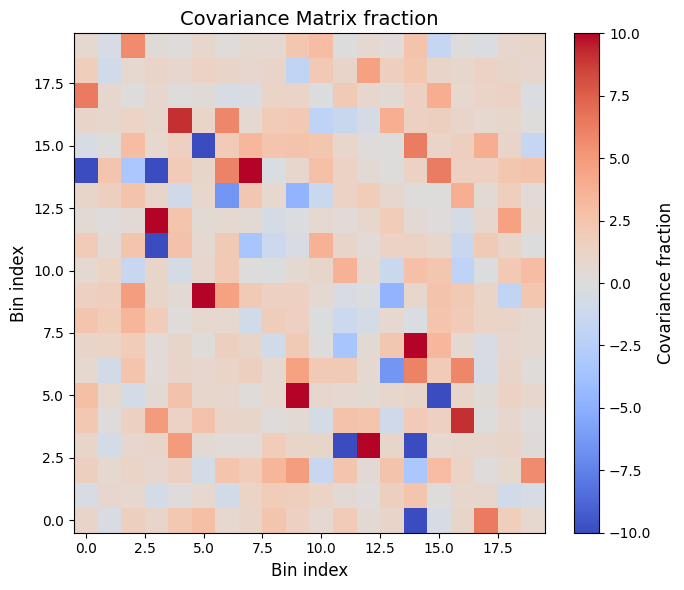

In [39]:
cov_fraction = GLIA_cov/IA_cov

plt.figure(figsize=(7,6))

im = plt.imshow(
    cov_fraction,
    origin='lower',
    cmap='coolwarm',
    aspect='auto',
    vmin=-10,
    vmax=10
)

cbar = plt.colorbar(im)
cbar.set_label('Covariance fraction', fontsize=12)

plt.title('Covariance Matrix fraction', fontsize=14)
plt.xlabel('Bin index', fontsize=12)
plt.ylabel('Bin index', fontsize=12)

plt.tight_layout()
plt.show()

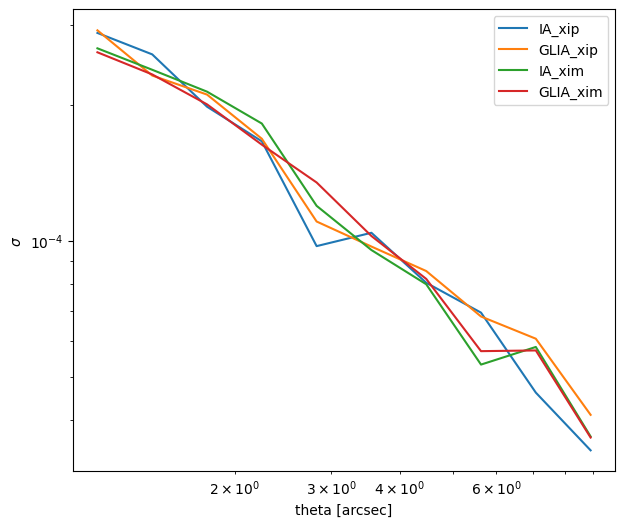

In [40]:
diag_IA_xip = np.diag(IA_cov)[:10]
diag_GLIA_xip = np.diag(GLIA_cov)[:10]

diag_IA_xim = np.diag(IA_cov)[10:]
diag_GLIA_xim = np.diag(GLIA_cov)[10:]

plt.figure(figsize=(7,6))

plt.plot(theta_as, np.sqrt(diag_IA_xip), label='IA_xip')
plt.plot(theta_as, np.sqrt(diag_GLIA_xip), label='GLIA_xip')
plt.plot(theta_as, np.sqrt(diag_IA_xim), label='IA_xim')
plt.plot(theta_as, np.sqrt(diag_GLIA_xim), label='GLIA_xim')
plt.legend()

plt.loglog()

plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\sigma$')
plt.show()